In [24]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [25]:
data = pd.read_csv(r"D:\FINAL\T1.csv")
data['Date/Time'] = pd.to_datetime(data['Date/Time'], format='%d %m %Y %H:%M')
data['Month'] = data['Date/Time'].dt.month
data['Day'] = data['Date/Time'].dt.day
data['Hour'] = data['Date/Time'].dt.hour
data['Minute'] = data['Date/Time'].dt.minute
data.set_index('Date/Time', inplace=True)

In [26]:
import pandas as pd
import numpy as np
from sklearn.preprocessing import MinMaxScaler
# Convert degrees to radians
data['Wind Direction (rad)'] = np.radians(data['Wind Direction (°)'])
# Transform into Cartesian coordinates
data['Wind Direction (x)'] = np.cos(data['Wind Direction (rad)'])
data['Wind Direction (y)'] = np.sin(data['Wind Direction (rad)'])
data= data.drop(columns=['Wind Direction (°)'])

In [27]:
data= data.drop(columns=['Theoretical_Power_Curve (KWh)'])

In [28]:
data

,LV ActivePower (kW),Wind Speed (m/s),Month,Day,Hour,Minute,Wind Direction (rad),Wind Direction (x),Wind Direction (y)
Date/Time,,,,,,,,,
2018-01-01 00:00:00,380.047791,5.311336,1,1,0,0,4.537767,-0.173736,-0.984792
2018-01-01 00:10:00,453.769196,5.672167,1,1,0,10,4.688672,-0.023715,-0.999719
2018-01-01 00:20:00,306.376587,5.216037,1,1,0,20,4.757153,0.044749,-0.998998
2018-01-01 00:30:00,419.645904,5.659674,1,1,0,30,4.734347,0.021956,-0.999759
2018-01-01 00:40:00,380.650696,5.577941,1,1,0,40,4.636891,-0.075426,-0.997151
...,...,...,...,...,...,...,...,...,...
2018-12-31 23:10:00,2963.980957,11.404030,12,31,23,10,1.405038,0.165001,0.986293
2018-12-31 23:20:00,1684.353027,7.332648,12,31,23,20,1.467169,0.103442,0.994636
2018-12-31 23:30:00,2201.106934,8.435358,12,31,23,30,1.479036,0.091632,0.995793


In [29]:
data['Month'] = (data['Month'] - 1) / 11 # Month ranges from 1 to 12
data['Day'] = (data['Day'] - 1) / 30 # Day ranges from 1 to 31
data['Hour'] = data['Hour'] / 23 # Hour ranges from 0 to 23
data['Minute'] = data['Minute'] / 59 # Minute ranges from 0 to 59

In [30]:
rows_with_negative_power = data[data['LV ActivePower (kW)'] < 0].index

# Drop these rows from the original DataFrame
data = data.drop(rows_with_negative_power)

In [31]:
rows_with_zero_power = data[data['LV ActivePower (kW)'] == 0].index
data = data.drop(rows_with_zero_power)

In [32]:
data

,LV ActivePower (kW),Wind Speed (m/s),Month,Day,Hour,Minute,Wind Direction (rad),Wind Direction (x),Wind Direction (y)
Date/Time,,,,,,,,,
2018-01-01 00:00:00,380.047791,5.311336,0.0,0.0,0.0,0.000000,4.537767,-0.173736,-0.984792
2018-01-01 00:10:00,453.769196,5.672167,0.0,0.0,0.0,0.169492,4.688672,-0.023715,-0.999719
2018-01-01 00:20:00,306.376587,5.216037,0.0,0.0,0.0,0.338983,4.757153,0.044749,-0.998998
2018-01-01 00:30:00,419.645904,5.659674,0.0,0.0,0.0,0.508475,4.734347,0.021956,-0.999759
2018-01-01 00:40:00,380.650696,5.577941,0.0,0.0,0.0,0.677966,4.636891,-0.075426,-0.997151
...,...,...,...,...,...,...,...,...,...
2018-12-31 23:10:00,2963.980957,11.404030,1.0,1.0,1.0,0.169492,1.405038,0.165001,0.986293
2018-12-31 23:20:00,1684.353027,7.332648,1.0,1.0,1.0,0.338983,1.467169,0.103442,0.994636
2018-12-31 23:30:00,2201.106934,8.435358,1.0,1.0,1.0,0.508475,1.479036,0.091632,0.995793


In [33]:
data = data.asfreq('10T')

# Fill missing values using forward fill and backward fill
data = data.interpolate(method='linear')

In [34]:
data['LV ActivePower (kW)'].describe()

count    52560.000000
mean      1305.205878
std       1290.761076
min          0.000200
25%        108.127527
50%        812.250480
75%       2435.702270
max       3618.732910
Name: LV ActivePower (kW), dtype: float64

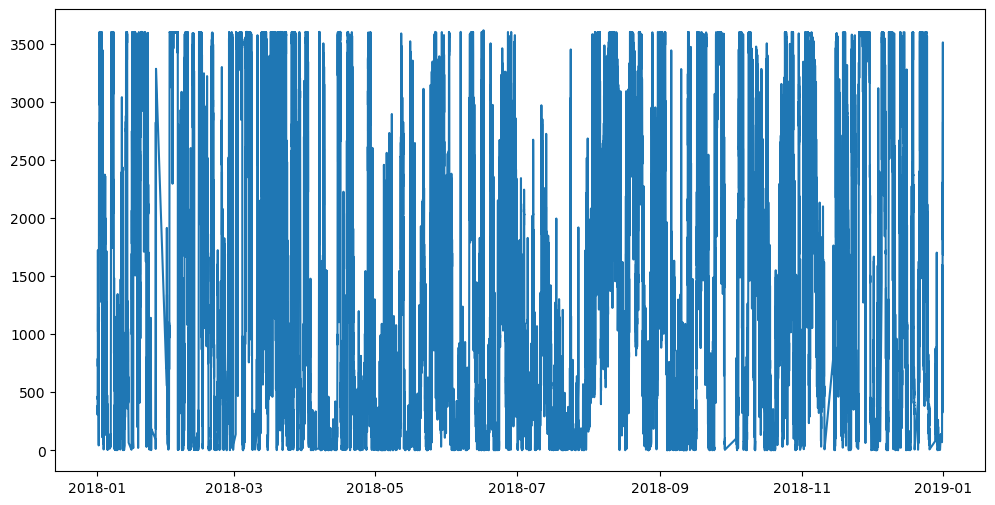

In [35]:
plt.figure(figsize=(12, 6)) 
plt.plot(data.index,data['LV ActivePower (kW)'].values)

In [36]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.preprocessing import MinMaxScaler
from vmdpy import VMD
scaler = MinMaxScaler()
columns_to_normalize = ['Wind Speed (m/s)','Wind Direction (rad)','Wind Direction (x)','Wind Direction (y)']
data[columns_to_normalize] = scaler.fit_transform(data[columns_to_normalize])

In [37]:
from sklearn.model_selection import train_test_split
train_data = data[data.index < '2018-12-01 00:00:00']
test_data = data[(data.index >= '2018-12-01 00:00:00') & (data.index <= '2018-12-31 23:50')]
# Check sizes of training and testing sets
print(f"Training set size: {len(train_data)} records")
print(f"Testing set size: {len(test_data)} records")

Training set size: 48096 records
Testing set size: 4464 records


In [38]:
test_data

,LV ActivePower (kW),Wind Speed (m/s),Month,Day,Hour,Minute,Wind Direction (rad),Wind Direction (x),Wind Direction (y)
Date/Time,,,,,,,,,
2018-12-01 00:00:00,57.407021,0.206610,1.0,0.0,0.000000,0.000000,0.132389,0.836766,0.869579
2018-12-01 00:10:00,27.440510,0.194832,1.0,0.0,0.000000,0.169492,0.138200,0.823050,0.881627
2018-12-01 00:20:00,0.364866,0.164986,1.0,0.0,0.000000,0.338983,0.150974,0.791414,0.906298
2018-12-01 00:30:00,0.503571,0.164127,1.0,0.0,0.007128,0.341762,0.152807,0.785980,0.907807
2018-12-01 00:40:00,0.642276,0.163269,1.0,0.0,0.014255,0.344540,0.154640,0.780545,0.909317
...,...,...,...,...,...,...,...,...,...
2018-12-31 23:10:00,2963.980957,0.424847,1.0,1.0,1.000000,0.169492,0.223620,0.582500,0.993147
2018-12-31 23:20:00,1684.353027,0.255186,1.0,1.0,1.000000,0.338983,0.233509,0.551721,0.997318
2018-12-31 23:30:00,2201.106934,0.301138,1.0,1.0,1.000000,0.508475,0.235397,0.545816,0.997896


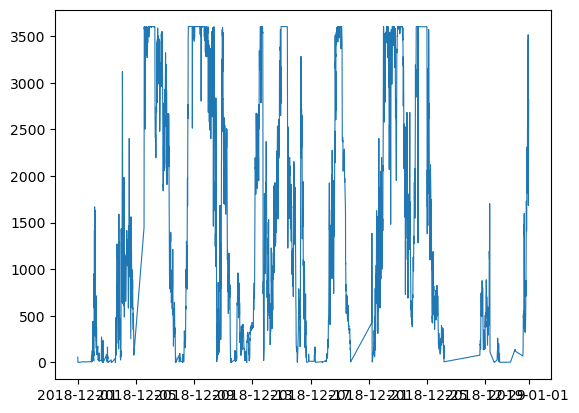

In [18]:
plt.plot(test_data.index,test_data['LV ActivePower (kW)'].values,linewidth=0.8)

In [39]:
train_data.to_csv(r"C:\Users\Leechita G\Desktop\8hr\train_norm.csv")

In [40]:
test_data.to_csv(r"C:\Users\Leechita G\Desktop\8hr\test_norm.csv")

In [41]:
test_data

,LV ActivePower (kW),Wind Speed (m/s),Month,Day,Hour,Minute,Wind Direction (rad),Wind Direction (x),Wind Direction (y)
Date/Time,,,,,,,,,
2018-12-01 00:00:00,57.407021,0.206610,1.0,0.0,0.000000,0.000000,0.132389,0.836766,0.869579
2018-12-01 00:10:00,27.440510,0.194832,1.0,0.0,0.000000,0.169492,0.138200,0.823050,0.881627
2018-12-01 00:20:00,0.364866,0.164986,1.0,0.0,0.000000,0.338983,0.150974,0.791414,0.906298
2018-12-01 00:30:00,0.503571,0.164127,1.0,0.0,0.007128,0.341762,0.152807,0.785980,0.907807
2018-12-01 00:40:00,0.642276,0.163269,1.0,0.0,0.014255,0.344540,0.154640,0.780545,0.909317
...,...,...,...,...,...,...,...,...,...
2018-12-31 23:10:00,2963.980957,0.424847,1.0,1.0,1.000000,0.169492,0.223620,0.582500,0.993147
2018-12-31 23:20:00,1684.353027,0.255186,1.0,1.0,1.000000,0.338983,0.233509,0.551721,0.997318
2018-12-31 23:30:00,2201.106934,0.301138,1.0,1.0,1.000000,0.508475,0.235397,0.545816,0.997896


In [42]:
scaler_modes = MinMaxScaler()
columns_to_normalize = ['LV ActivePower (kW)']
test_norm = scaler.fit_transform(test_data[columns_to_normalize])

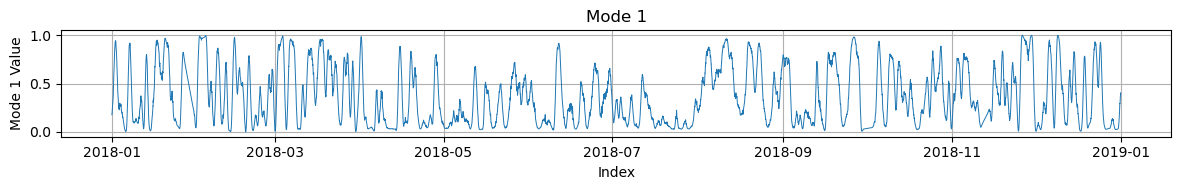

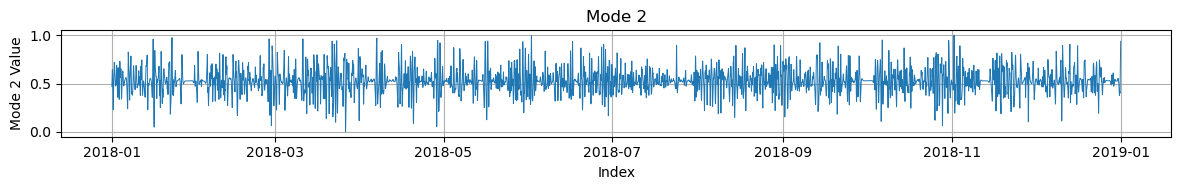

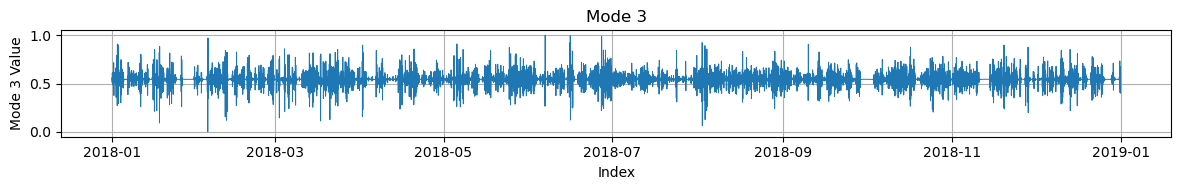

In [43]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.preprocessing import MinMaxScaler
from vmdpy import VMD

# Example parameters for VMD
alpha = 2000  # Moderate bandwidth constraint
tau = 0  # Noise-tolerance (no strict fidelity enforcement)
K = 3  # Number of modes
DC = 0  # No DC part imposed
init = 1  # Initialize omegas uniformly
tol = 1e-7  # Tolerance for convergence

# Ensure 'data' is your DataFrame and 'LV ActivePower (kW)' is one of its columns
signal = data['LV ActivePower (kW)'].values

# Perform VMD
modes, residuals, omega = VMD(signal, alpha, tau, K, DC, init, tol)

# Normalize each mode
scaler_modes = MinMaxScaler()
modes_normalized = scaler_modes.fit_transform(modes.T).T  # Transpose for correct scaling

# Create DataFrames for each mode
mode_dfs = []
for mode_index in range(K):
    mode_df = pd.DataFrame(index=data.index[:modes_normalized.shape[1]])  # Ensure correct length
    mode_df['LV ActivePower (kW)'] = modes_normalized[mode_index]
    mode_df['Wind Speed (m/s)'] = data['Wind Speed (m/s)'].values[:modes_normalized.shape[1]]
    mode_df['Month'] = data['Month'].values[:modes_normalized.shape[1]]
    mode_df['Day'] = data['Day'].values[:modes_normalized.shape[1]]
    mode_df['Hour'] = data['Hour'].values[:modes_normalized.shape[1]]
    mode_df['Minute'] = data['Minute'].values[:modes_normalized.shape[1]]
    mode_df['Wind Direction (rad)'] = data['Wind Direction (rad)'].values[:modes_normalized.shape[1]]
    mode_df['Wind Direction (x)'] = data['Wind Direction (x)'].values[:modes_normalized.shape[1]]
    mode_df['Wind Direction (y)'] = data['Wind Direction (y)'].values[:modes_normalized.shape[1]]
    mode_dfs.append(mode_df)

    # Plotting the modes as subplots
    plt.figure(figsize=(12, 2))
    plt.plot(mode_df.index, mode_df['LV ActivePower (kW)'], label=f'Mode {mode_index+1}',linewidth=0.7)
    plt.title(f'Mode {mode_index+1}')
    plt.ylabel(f'Mode {mode_index+1} Value')
    plt.xlabel('Index')
    plt.grid(True)
    plt.tight_layout()
    plt.show()

# Save each mode DataFrame into separate variables (if needed)
mode1_df, mode2_df, mode3_df = mode_dfs


In [44]:
act_mode = modes_normalized[0] + modes_normalized[1] + modes_normalized[2]

In [45]:
modes_normalized

array([[0.17708022, 0.17724182, 0.17736484, ..., 0.3937919 , 0.39548895,
        0.39706362],
       [0.47118022, 0.47202593, 0.47349067, ..., 0.92890503, 0.93325154,
        0.93631473],
       [0.55544566, 0.55442005, 0.55211183, ..., 0.43591619, 0.41109397,
        0.40005957]])

In [46]:
mode1_df.to_csv(r"C:\Users\Leechita G\Desktop\8hr\imf\imf1.csv")
mode2_df.to_csv(r"C:\Users\Leechita G\Desktop\8hr\imf\imf2.csv")
mode3_df.to_csv(r"C:\Users\Leechita G\Desktop\8hr\imf\imf3.csv")

# IMF3

Train dates : 2018-01-01 00:00:00 --- 2018-11-30 23:50:00  (n=48096)
Test dates  : 2018-12-01 00:00:00 --- 2018-12-31 23:50:00  (n=4464)


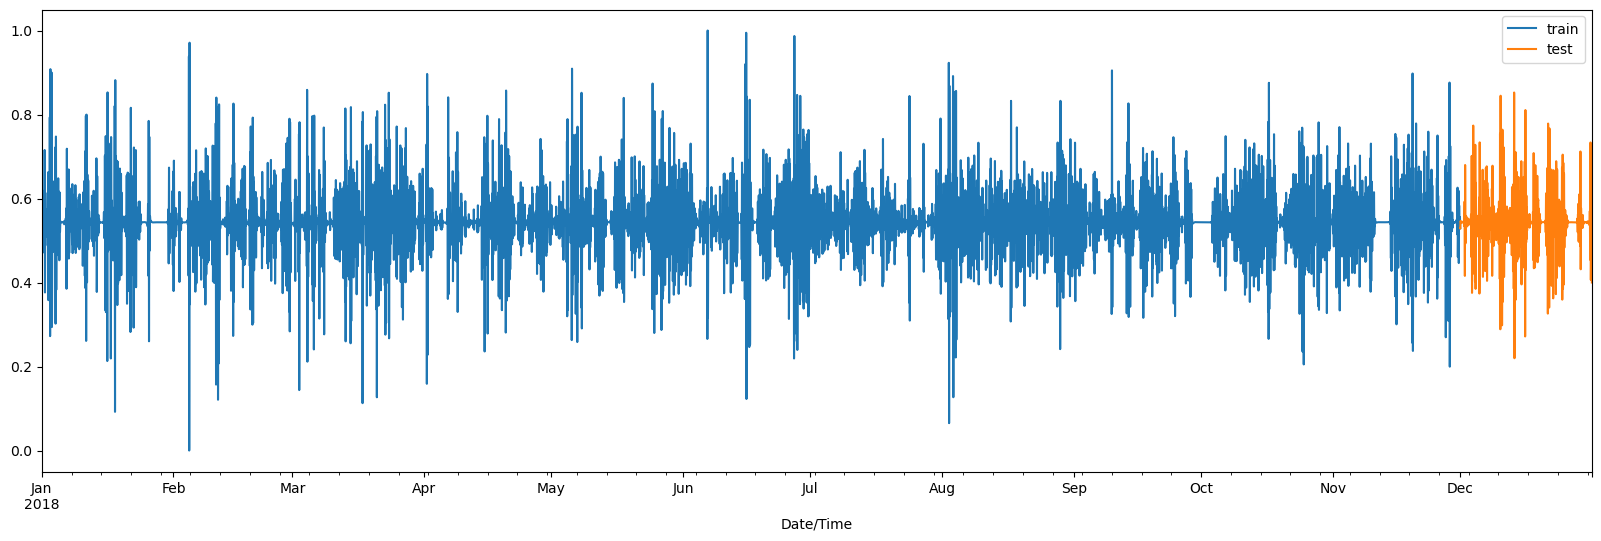

In [47]:
import pandas as pd
import matplotlib.pyplot as plt
from skforecast.ForecasterAutoreg import ForecasterAutoreg

# Load your data (replace with your actual file path)
imf3 = pd.read_csv(r"C:\Users\Leechita G\Desktop\8hr\imf\imf3.csv")
imf3['Date/Time'] = pd.to_datetime(imf3['Date/Time'])
imf3.set_index('Date/Time', inplace=True)
imf3 = imf3.asfreq('10T')

# Train-test split
steps = 4464
imf3_train = imf3[:-steps]
imf3_test = imf3[-steps:]
columns_to_predict = ['LV ActivePower (kW)']
X_train = imf3_train.drop(columns=columns_to_predict)
y_train = imf3_train[columns_to_predict]
X_test = imf3_test.drop(columns=columns_to_predict)
y_test=imf3_test[columns_to_predict]
y_train=y_train['LV ActivePower (kW)']
print(
    f"Train dates : {imf3_train.index.min()} --- "
    f"{imf3_train.index.max()}  (n={len(imf3_train)})"
)
print(
    f"Test dates  : {imf3_test.index.min()} --- "
    f"{imf3_test.index.max()}  (n={len(imf3_test)})"
)

fig, ax = plt.subplots(figsize=(20, 6))
imf3_train['LV ActivePower (kW)'].plot(ax=ax, label='train')
imf3_test['LV ActivePower (kW)'].plot(ax=ax, label='test')
ax.legend();

In [51]:

from xgboost import XGBRegressor
forecaster = ForecasterAutoreg(
    regressor=XGBRegressor(objective='reg:squarederror', n_estimators=800, learning_rate=0.01),
    lags=48
)

# Initial training
forecaster.fit(y_train, exog=X_train)

In [52]:
steps = 48
predictions = forecaster.predict(steps=steps,exog=X_test[:48])
# Add datetime index to predictions
predictions = pd.Series(data=predictions, index=y_test[:48].index)

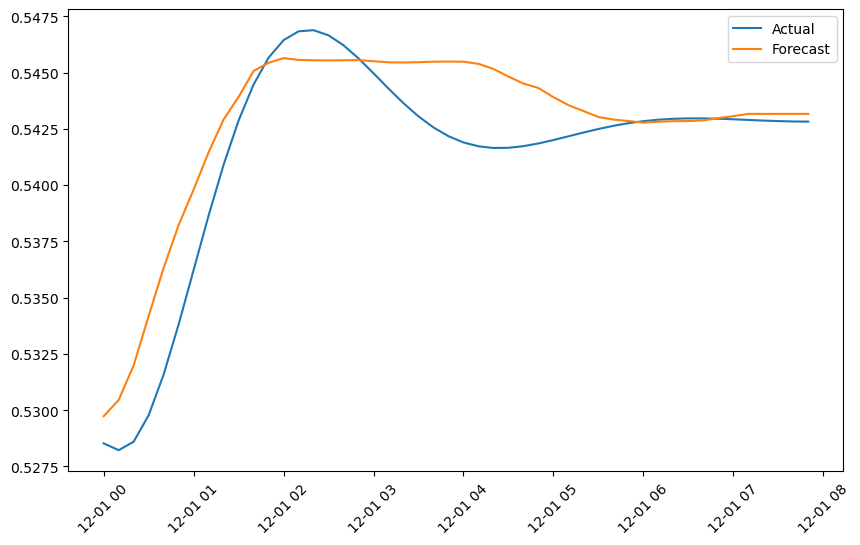

In [54]:
plt.figure(figsize=(10, 6))
plt.plot(y_test[:48].index, y_test['LV ActivePower (kW)'][:48], label='Actual')
plt.plot(y_test[:48].index, predictions, label='Forecast')
plt.xticks(rotation=45)
plt.legend()
plt.show()

In [56]:
import numpy as np
from sklearn.metrics import mean_squared_error

# Define sMAPE function
def calculate_smape(y_true, y_pred):
    return 100 * np.mean(2 * np.abs(y_pred - y_true) / (np.abs(y_true) + np.abs(y_pred)))

# Calculate MSE
error_mse = mean_squared_error(y_true=y_test['LV ActivePower (kW)'][:48], y_pred=predictions)
print(f"Test error (MSE): {error_mse}")

# Calculate sMAPE
error_smape = calculate_smape(y_true=y_test['LV ActivePower (kW)'][:48], y_pred=predictions)
print(f"Test error (sMAPE): {error_smape:.2f}%")

Test error (MSE): 4.403526679814974e-06
Test error (sMAPE): 0.29%


In [57]:
predictions

Date/Time
2018-12-01 00:00:00    0.529733
2018-12-01 00:10:00    0.530453
2018-12-01 00:20:00    0.531995
2018-12-01 00:30:00    0.534187
2018-12-01 00:40:00    0.536326
2018-12-01 00:50:00    0.538231
2018-12-01 01:00:00    0.539805
2018-12-01 01:10:00    0.541464
2018-12-01 01:20:00    0.542919
2018-12-01 01:30:00    0.543923
2018-12-01 01:40:00    0.545076
2018-12-01 01:50:00    0.545438
2018-12-01 02:00:00    0.545645
2018-12-01 02:10:00    0.545565
2018-12-01 02:20:00    0.545549
2018-12-01 02:30:00    0.545541
2018-12-01 02:40:00    0.545550
2018-12-01 02:50:00    0.545557
2018-12-01 03:00:00    0.545510
2018-12-01 03:10:00    0.545459
2018-12-01 03:20:00    0.545452
2018-12-01 03:30:00    0.545465
2018-12-01 03:40:00    0.545487
2018-12-01 03:50:00    0.545493
2018-12-01 04:00:00    0.545487
2018-12-01 04:10:00    0.545392
2018-12-01 04:20:00    0.545165
2018-12-01 04:30:00    0.544827
2018-12-01 04:40:00    0.544516
2018-12-01 04:50:00    0.544320
2018-12-01 05:00:00    0.54391

In [58]:
# Create a DataFrame for forecasted values with y_test index
forecasted_values_df = pd.DataFrame(predictions.values, index=y_test[:48].index, columns=['Forecasted Values'])

# Print the forecasted values DataFrame
forecasted_values_df

,Forecasted Values
Date/Time,
2018-12-01 00:00:00,0.529733
2018-12-01 00:10:00,0.530453
2018-12-01 00:20:00,0.531995
2018-12-01 00:30:00,0.534187
2018-12-01 00:40:00,0.536326
2018-12-01 00:50:00,0.538231
2018-12-01 01:00:00,0.539805
2018-12-01 01:10:00,0.541464
2018-12-01 01:20:00,0.542919


In [59]:
y_test.to_csv(r"C:\Users\Leechita G\Desktop\8hr\imf\imf3_test.csv")

In [60]:
forecasted_values_df.to_csv(r"C:\Users\Leechita G\Desktop\8hr\imf\imf3_pred.csv")

# IMF2

# SVR

In [106]:
import pandas as pd
import matplotlib.pyplot as plt
from skforecast.ForecasterAutoreg import ForecasterAutoreg
from sklearn.svm import SVR
import numpy as np
from sklearn.metrics import mean_squared_error

# Load your data (replace with your actual file path)
imf2 = pd.read_csv(r"C:\Users\Leechita G\Desktop\8hr\imf\imf2.csv")
imf2['Date/Time'] = pd.to_datetime(imf2['Date/Time'])
imf2.set_index('Date/Time', inplace=True)
imf2 = imf2.asfreq('10T')

steps = 4464
imf2_train = imf2[:-steps]
imf2_test = imf2[-steps:]

columns_to_predict = ['LV ActivePower (kW)']
X_train = imf2_train.drop(columns=columns_to_predict)
y_train = imf2_train[columns_to_predict]
X_test = imf2_test.drop(columns=columns_to_predict)
y_test = imf2_test[columns_to_predict]
y_train = y_train['LV ActivePower (kW)']


from xgboost import XGBRegressor
forecaster = ForecasterAutoreg(
    regressor=XGBRegressor(objective='reg:squarederror', n_estimators=800, learning_rate=0.1),
    lags=65
)

# Initial training
forecaster.fit(y_train, exog=X_train)

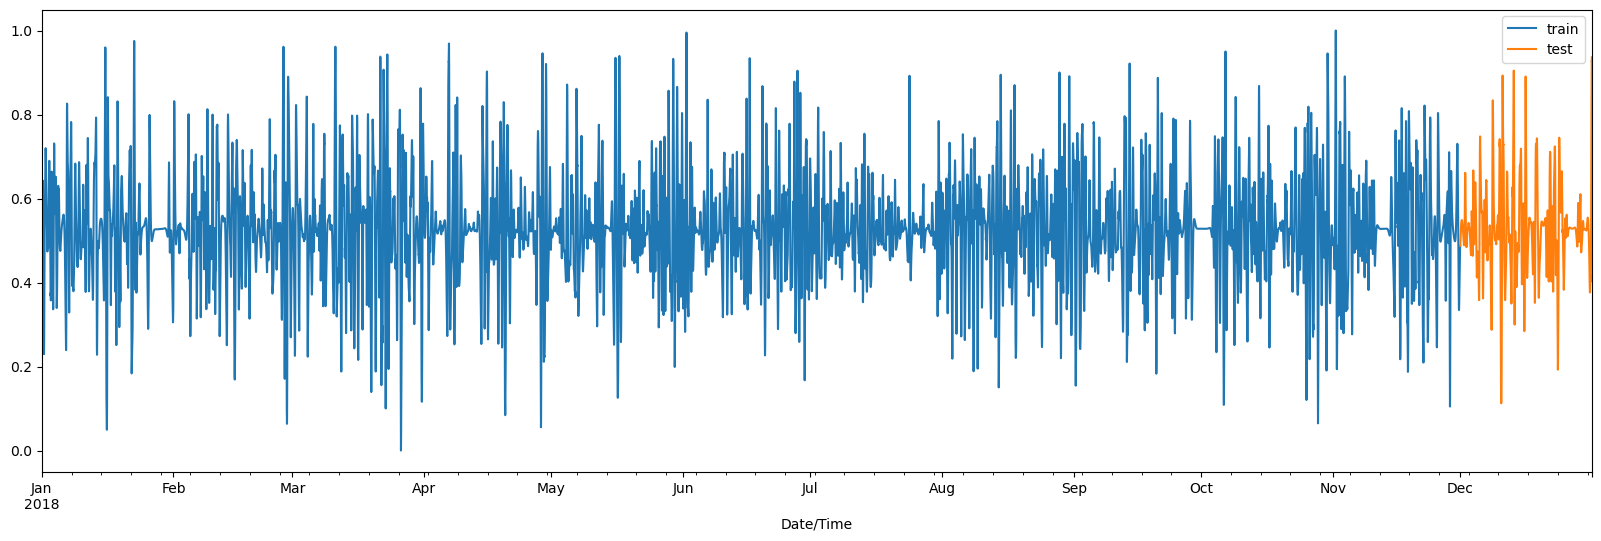

In [107]:
fig, ax = plt.subplots(figsize=(20, 6))
imf2_train['LV ActivePower (kW)'].plot(ax=ax, label='train')
imf2_test['LV ActivePower (kW)'].plot(ax=ax, label='test')
ax.legend();

In [108]:
steps = 48
predictions = forecaster.predict(steps=steps,exog=X_test[:48])
# Add datetime index to predictions
predictions = pd.Series(data=predictions, index=y_test[:48].index)

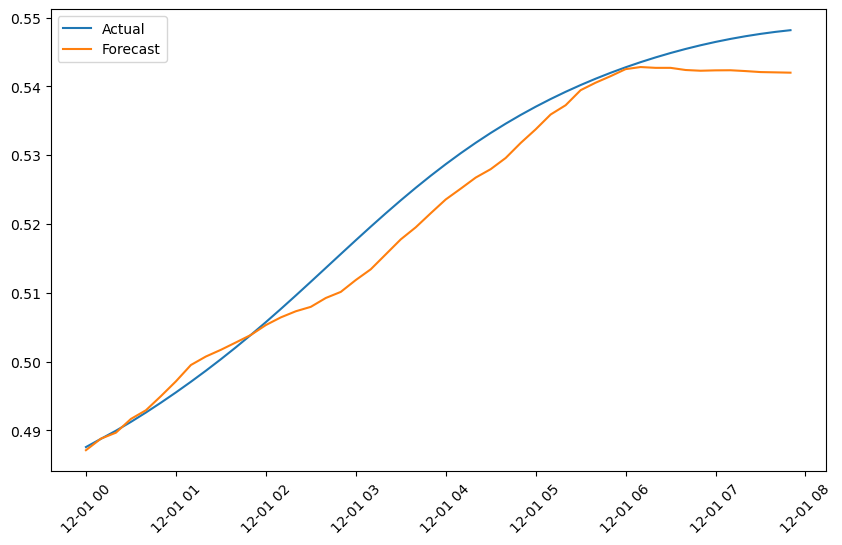

In [109]:
plt.figure(figsize=(10, 6))
plt.plot(y_test[:48].index, y_test['LV ActivePower (kW)'][:48], label='Actual')
plt.plot(y_test[:48].index, predictions, label='Forecast')
plt.xticks(rotation=45)
plt.legend()
plt.show()

In [110]:
import numpy as np
from sklearn.metrics import mean_squared_error

# Define sMAPE function
def calculate_smape(y_true, y_pred):
    return 100 * np.mean(2 * np.abs(y_pred - y_true) / (np.abs(y_true) + np.abs(y_pred)))

# Calculate MSE
error_mse = mean_squared_error(y_true=y_test['LV ActivePower (kW)'][:48], y_pred=predictions)
print(f"Test error (MSE): {error_mse}")

# Calculate sMAPE
error_smape = calculate_smape(y_true=y_test['LV ActivePower (kW)'][:48], y_pred=predictions)
print(f"Test error (sMAPE): {error_smape:.2f}%")

Test error (MSE): 1.364210794263177e-05
Test error (sMAPE): 0.57%


In [111]:
# Create a DataFrame for forecasted values with y_test index
forecasted_values_df = pd.DataFrame(predictions.values, index=y_test[:48].index, columns=['Forecasted Values'])

# Print the forecasted values DataFrame
forecasted_values_df

,Forecasted Values
Date/Time,
2018-12-01 00:00:00,0.487109
2018-12-01 00:10:00,0.488787
2018-12-01 00:20:00,0.489654
2018-12-01 00:30:00,0.491653
2018-12-01 00:40:00,0.492911
2018-12-01 00:50:00,0.494964
2018-12-01 01:00:00,0.497112
2018-12-01 01:10:00,0.499490
2018-12-01 01:20:00,0.500725


In [112]:
y_test.to_csv(r"C:\Users\Leechita G\Desktop\8hr\imf\imf2_test.csv")

In [113]:
forecasted_values_df.to_csv(r"C:\Users\Leechita G\Desktop\8hr\imf\imf2_pred.csv")

# IMF1

# SVR

In [176]:
import pandas as pd
import matplotlib.pyplot as plt
from skforecast.ForecasterAutoreg import ForecasterAutoreg
from sklearn.svm import SVR
import numpy as np
from sklearn.metrics import mean_squared_error

# Load your data (replace with your actual file path)
imf1 = pd.read_csv(r"C:\Users\Leechita G\Desktop\8hr\imf\imf1.csv")
imf1['Date/Time'] = pd.to_datetime(imf1['Date/Time'])
imf1.set_index('Date/Time', inplace=True)
imf1 = imf1.asfreq('10T')

In [177]:

steps = 4464
imf1_train = imf1[:-steps]
imf1_test = imf1[-steps:]

columns_to_predict = ['LV ActivePower (kW)']
X_train = imf1_train.drop(columns=columns_to_predict)
y_train = imf1_train[columns_to_predict]
X_test = imf1_test.drop(columns=columns_to_predict)
y_test = imf1_test[columns_to_predict]
y_train = y_train['LV ActivePower (kW)']

from xgboost import XGBRegressor
forecaster = ForecasterAutoreg(
    regressor=XGBRegressor(objective='reg:squarederror', n_estimators=1000, learning_rate=0.1),
    lags=48
)

# Initial training
forecaster.fit(y_train, exog=X_train)


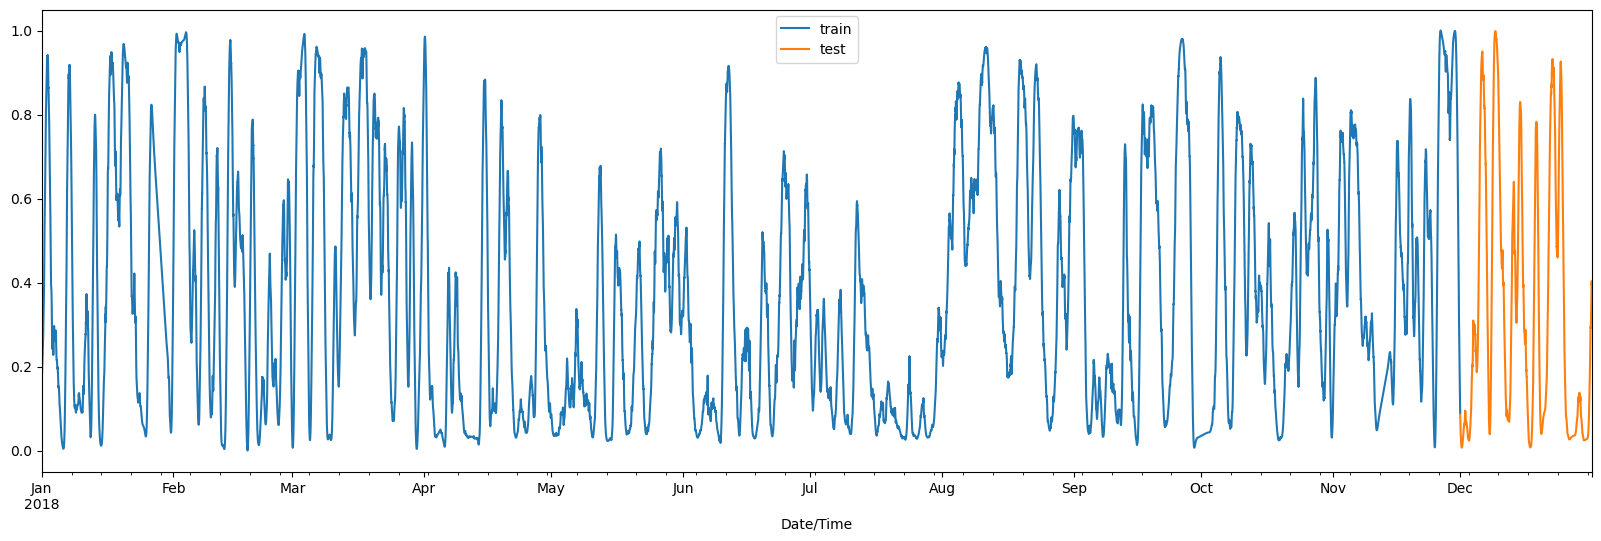

In [178]:
fig, ax = plt.subplots(figsize=(20, 6))
imf1_train['LV ActivePower (kW)'].plot(ax=ax, label='train')
imf1_test['LV ActivePower (kW)'].plot(ax=ax, label='test')
ax.legend();

In [179]:
steps = 48
predictions = forecaster.predict(steps=steps,exog=X_test[:48])
# Add datetime index to predictions
predictions = pd.Series(data=predictions, index=y_test[:48].index)

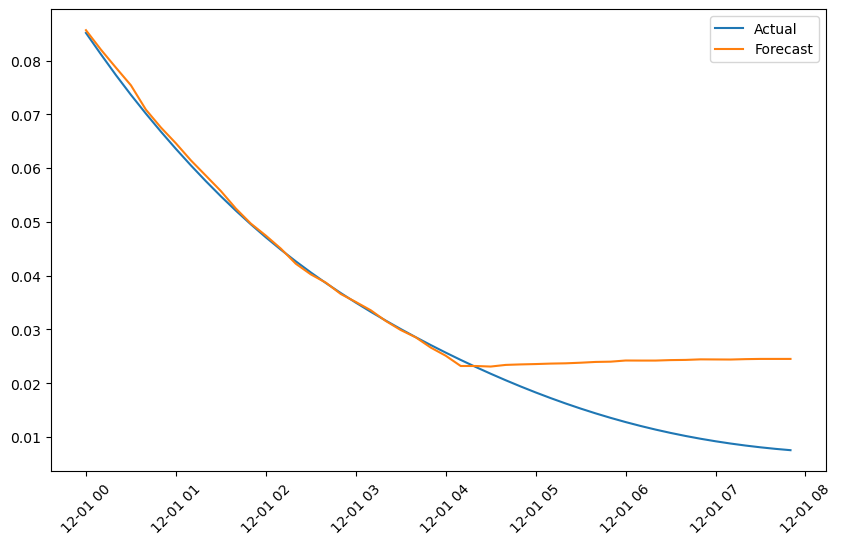

In [180]:
plt.figure(figsize=(10, 6))
plt.plot(y_test[:48].index, y_test['LV ActivePower (kW)'][:48], label='Actual')
plt.plot(y_test[:48].index, predictions, label='Forecast')
plt.xticks(rotation=45)
plt.legend()
plt.show()

In [181]:
import numpy as np
from sklearn.metrics import mean_squared_error

# Define sMAPE function
def calculate_smape(y_true, y_pred):
    return 100 * np.mean(2 * np.abs(y_pred - y_true) / (np.abs(y_true) + np.abs(y_pred)))

# Calculate MSE
error_mse = mean_squared_error(y_true=y_test['LV ActivePower (kW)'][:48], y_pred=predictions)
print(f"Test error (MSE): {error_mse}")

# Calculate sMAPE
error_smape = calculate_smape(y_true=y_test['LV ActivePower (kW)'][:48], y_pred=predictions)
print(f"Test error (sMAPE): {error_smape:.2f}%")

Test error (MSE): 6.36474430683884e-05
Test error (sMAPE): 28.15%


In [182]:
# Create a DataFrame for forecasted values with y_test index
forecasted_values_df = pd.DataFrame(predictions.values, index=y_test[:48].index, columns=['Forecasted Values'])

# Print the forecasted values DataFrame
forecasted_values_df

,Forecasted Values
Date/Time,
2018-12-01 00:00:00,0.085647
2018-12-01 00:10:00,0.082024
2018-12-01 00:20:00,0.078676
2018-12-01 00:30:00,0.075398
2018-12-01 00:40:00,0.070864
2018-12-01 00:50:00,0.067551
2018-12-01 01:00:00,0.064615
2018-12-01 01:10:00,0.061443
2018-12-01 01:20:00,0.058596


In [184]:
y_test.to_csv(r"C:\Users\Leechita G\Desktop\8hr\imf\imf1_test.csv")

In [185]:
forecasted_values_df.to_csv(r"C:\Users\Leechita G\Desktop\8hr\imf\imf1_pred.csv")

# INTEGRATION

In [242]:
import pandas as pd

In [243]:
imf1= pd.read_csv(r"C:\Users\Leechita G\Desktop\8hr\imf\imf1_pred.csv")

In [244]:
imf1

,Date/Time,Forecasted Values
0,2018-12-01 00:00:00,0.085647
1,2018-12-01 00:10:00,0.082024
2,2018-12-01 00:20:00,0.078676
3,2018-12-01 00:30:00,0.075398
4,2018-12-01 00:40:00,0.070864
5,2018-12-01 00:50:00,0.067551
6,2018-12-01 01:00:00,0.064615
7,2018-12-01 01:10:00,0.061443
8,2018-12-01 01:20:00,0.058596
9,2018-12-01 01:30:00,0.055738


In [245]:
imf2= pd.read_csv(r"C:\Users\Leechita G\Desktop\8hr\imf\imf2_pred.csv")

In [246]:
imf2

,Date/Time,Forecasted Values
0,2018-12-01 00:00:00,0.487109
1,2018-12-01 00:10:00,0.488787
2,2018-12-01 00:20:00,0.489654
3,2018-12-01 00:30:00,0.491653
4,2018-12-01 00:40:00,0.492911
5,2018-12-01 00:50:00,0.494964
6,2018-12-01 01:00:00,0.497112
7,2018-12-01 01:10:00,0.499490
8,2018-12-01 01:20:00,0.500725
9,2018-12-01 01:30:00,0.501698


In [247]:
imf3= pd.read_csv(r"C:\Users\Leechita G\Desktop\8hr\imf\imf3_pred.csv")

In [248]:
imf3

,Date/Time,Forecasted Values
0,2018-12-01 00:00:00,0.529733
1,2018-12-01 00:10:00,0.530453
2,2018-12-01 00:20:00,0.531995
3,2018-12-01 00:30:00,0.534187
4,2018-12-01 00:40:00,0.536326
5,2018-12-01 00:50:00,0.538231
6,2018-12-01 01:00:00,0.539805
7,2018-12-01 01:10:00,0.541464
8,2018-12-01 01:20:00,0.542919
9,2018-12-01 01:30:00,0.543923


In [249]:
imf1=imf1.set_index('Date/Time')

In [250]:
imf2=imf2.set_index('Date/Time')

In [251]:
imf3=imf3.set_index('Date/Time')

In [252]:
imf_all = pd.concat([imf1, imf2, imf3], axis=1)

In [253]:
imf_all.columns = ['IMF1','IMF2','IMF3']

In [376]:
weights = [0.99,2.15,0.35]

In [377]:
imf_all['Integrated'] = (imf_all['IMF1']*weights[0] + imf_all['IMF2'] * weights[1] + imf_all ['IMF3'] * weights[2])

In [378]:
imf_all

,IMF1,IMF2,IMF3,Integrated
Date/Time,,,,
2018-12-01 00:00:00,0.085647,0.487109,0.529733,1.317480
2018-12-01 00:10:00,0.082024,0.488787,0.530453,1.317753
2018-12-01 00:20:00,0.078676,0.489654,0.531995,1.316844
2018-12-01 00:30:00,0.075398,0.491653,0.534187,1.318663
2018-12-01 00:40:00,0.070864,0.492911,0.536326,1.317628
2018-12-01 00:50:00,0.067551,0.494964,0.538231,1.319428
2018-12-01 01:00:00,0.064615,0.497112,0.539805,1.321692
2018-12-01 01:10:00,0.061443,0.499490,0.541464,1.324243
2018-12-01 01:20:00,0.058596,0.500725,0.542919,1.324590


In [379]:
pred = imf_all['Integrated'].values

In [380]:
pred

array([1.31748032, 1.31775343, 1.31684436, 1.31866347, 1.31762762,
       1.31942847, 1.32169162, 1.32424316, 1.32459029, 1.32420442,
       1.32369305, 1.32338657, 1.32434533, 1.32432927, 1.32344113,
       1.32286216, 1.32411767, 1.32392822, 1.32615589, 1.32796347,
       1.33066264, 1.33367372, 1.33611223, 1.33863388, 1.34143053,
       1.34288108, 1.34626641, 1.34867732, 1.3523668 , 1.35708074,
       1.36125972, 1.36586797, 1.36872432, 1.37344666, 1.37588846,
       1.37795651, 1.38034211, 1.38099487, 1.38075211, 1.38084008,
       1.38021252, 1.38012067, 1.38025215, 1.38030291, 1.38011968,
       1.37985061, 1.37975834, 1.3796612 ])

In [381]:
act_mode[:48]

array([1.20370611, 1.20368779, 1.20296734, 1.20368511, 1.20476226,
       1.20670387, 1.20948945, 1.21290078, 1.21805651, 1.22449879,
       1.23267743, 1.24225864, 1.25247651, 1.2610677 , 1.26900888,
       1.27595024, 1.28253376, 1.2911522 , 1.30356528, 1.32125856,
       1.34471724, 1.37494483, 1.40750876, 1.43712644, 1.46391644,
       1.4797922 , 1.4795974 , 1.46601982, 1.44618281, 1.42796748,
       1.41444419, 1.40447018, 1.39902769, 1.39658324, 1.395983  ,
       1.39662357, 1.39810838, 1.39981247, 1.40014427, 1.39788722,
       1.39103742, 1.38212775, 1.37239885, 1.36166895, 1.34765964,
       1.32905912, 1.30616047, 1.28162924])

In [382]:
og= act_mode[:48]

In [383]:
og

array([1.20370611, 1.20368779, 1.20296734, 1.20368511, 1.20476226,
       1.20670387, 1.20948945, 1.21290078, 1.21805651, 1.22449879,
       1.23267743, 1.24225864, 1.25247651, 1.2610677 , 1.26900888,
       1.27595024, 1.28253376, 1.2911522 , 1.30356528, 1.32125856,
       1.34471724, 1.37494483, 1.40750876, 1.43712644, 1.46391644,
       1.4797922 , 1.4795974 , 1.46601982, 1.44618281, 1.42796748,
       1.41444419, 1.40447018, 1.39902769, 1.39658324, 1.395983  ,
       1.39662357, 1.39810838, 1.39981247, 1.40014427, 1.39788722,
       1.39103742, 1.38212775, 1.37239885, 1.36166895, 1.34765964,
       1.32905912, 1.30616047, 1.28162924])

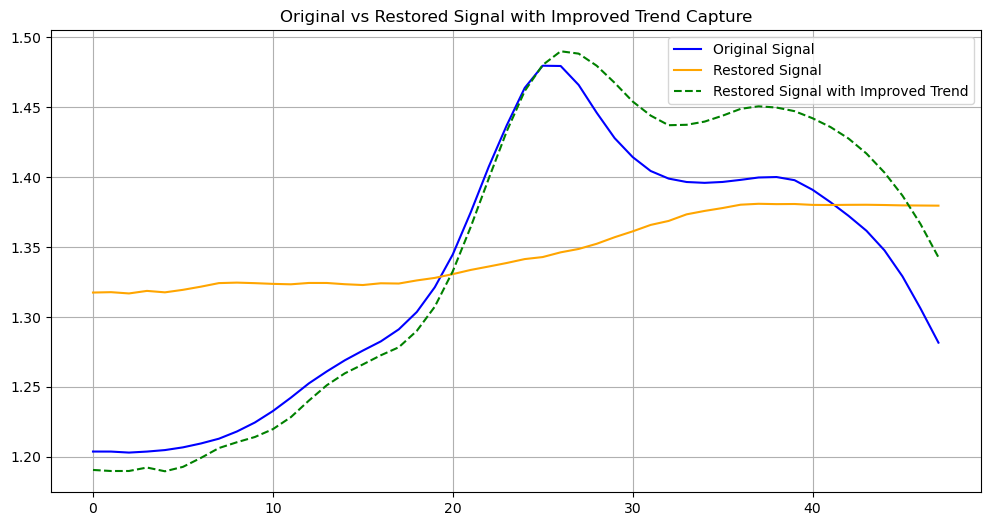

In [384]:
import numpy as np
import matplotlib.pyplot as plt
from numpy.polynomial import Polynomial
from scipy.ndimage import uniform_filter1d


# Fit a higher-order polynomial to the original signal
degree = 16 # You can adjust this degree for better fitting
poly = Polynomial.fit(range(len(og)), og, deg=degree)
trend_poly = poly(range(len(og)))

# Apply a moving average to smooth the trend
window_size = 2 # Adjust window size as needed
trend_smoothed = uniform_filter1d(trend_poly, size=window_size)

# Add the smoothed trend to the restored signal
restored_signal_with_trend = pred + (trend_smoothed - np.mean(trend_smoothed))

# Plot the results
plt.figure(figsize=(12, 6))
plt.plot(range(len(og)), og, label='Original Signal', color='blue')
plt.plot(range(len(pred)), pred, label='Restored Signal', color='orange')
plt.plot(range(len(trend_smoothed)), restored_signal_with_trend, 
         label='Restored Signal with Improved Trend', linestyle='--', color='green')
plt.title('Original vs Restored Signal with Improved Trend Capture')
plt.legend()
plt.grid(True)
plt.show()


In [385]:
pred = restored_signal_with_trend

In [386]:
pred

array([1.19054073, 1.18978208, 1.18979091, 1.19226507, 1.18958829,
       1.19274874, 1.19915999, 1.20620417, 1.21036607, 1.21412025,
       1.21973354, 1.22830689, 1.24014829, 1.25118494, 1.25967929,
       1.26602929, 1.2725848 , 1.27832931, 1.29003969, 1.30736149,
       1.33266975, 1.36447046, 1.39903188, 1.43285758, 1.46170118,
       1.48032934, 1.49012841, 1.4884432 , 1.47979321, 1.4675553 ,
       1.4542015 , 1.44412687, 1.43722449, 1.43752018, 1.43980485,
       1.4440497 , 1.44890021, 1.45078957, 1.44985173, 1.44727692,
       1.44221145, 1.43589794, 1.42769977, 1.41694178, 1.40334209,
       1.38683482, 1.36656396, 1.34270414])

In [387]:
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score

In [388]:
rmse = mean_squared_error(og, pred, squared=False)
print(f"RMSE: {rmse}")

# Calculate and print the MAE
mae = mean_absolute_error(og, pred)
print(f"MAE: {mae}")

# Calculate and print R-squared
r2 = r2_score(og, pred)
print(f"R-squared: {r2}")

# Calculate and print sMAPE
#def smape(A, F):
    #return 100 * np.mean(2 * np.abs(pred-og) / (np.abs(og) + np.abs(pred)))

#smape_value = smape(og, pred)
#print(f"sMAPE: {smape_value}")

# Calculate and print MAPE
mape = np.mean(np.abs((og - pred) / og)) * 100
print(f"Mean Absolute Percentage Error (MAPE): {mape}%")

RMSE: 0.033071439779247015
MAE: 0.026661089653657367
R-squared: 0.8588681050657337
Mean Absolute Percentage Error (MAPE): 1.9730014011258667%


matplotlib.category INFO  Using categorical units to plot a list of strings that are all parsable as floats or dates. If these strings should be plotted as numbers, cast to the appropriate data type before plotting.
matplotlib.category INFO  Using categorical units to plot a list of strings that are all parsable as floats or dates. If these strings should be plotted as numbers, cast to the appropriate data type before plotting.
matplotlib.category INFO  Using categorical units to plot a list of strings that are all parsable as floats or dates. If these strings should be plotted as numbers, cast to the appropriate data type before plotting.
matplotlib.category INFO  Using categorical units to plot a list of strings that are all parsable as floats or dates. If these strings should be plotted as numbers, cast to the appropriate data type before plotting.


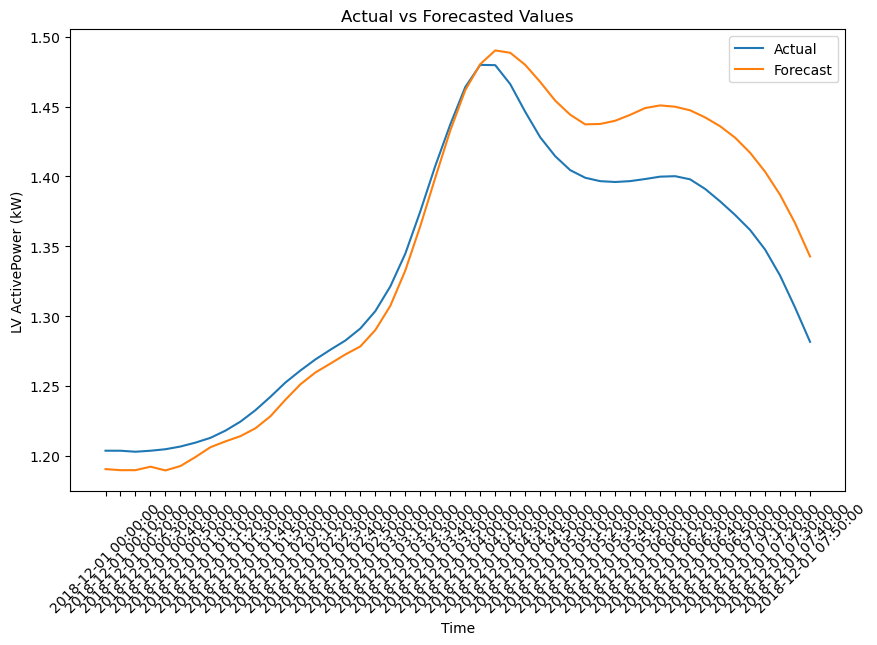

In [389]:
# Plot the actual vs forecasted values
plt.figure(figsize=(10, 6))
plt.plot(imf_all.index, og, label='Actual')
plt.plot(imf_all.index, pred, label='Forecast')
plt.xticks(rotation=45)
plt.legend()
plt.title('Actual vs Forecasted Values')
plt.xlabel('Time')
plt.ylabel('LV ActivePower (kW)')
plt.show()

In [390]:
# Create a DataFrame for forecasted values with y_test index
pred_df = pd.DataFrame(pred, index=y_test[:48].index, columns=['Pred'])

# Print the forecasted 
pred_df

,Pred
Date/Time,
2018-12-01 00:00:00,1.190541
2018-12-01 00:10:00,1.189782
2018-12-01 00:20:00,1.189791
2018-12-01 00:30:00,1.192265
2018-12-01 00:40:00,1.189588
2018-12-01 00:50:00,1.192749
2018-12-01 01:00:00,1.199160
2018-12-01 01:10:00,1.206204
2018-12-01 01:20:00,1.210366


In [391]:
# Create a DataFrame for forecasted values with y_test index
og_df = pd.DataFrame(og, index=y_test[:48].index, columns=['Og'])

# Print the forecasted 
og_df

,Og
Date/Time,
2018-12-01 00:00:00,1.203706
2018-12-01 00:10:00,1.203688
2018-12-01 00:20:00,1.202967
2018-12-01 00:30:00,1.203685
2018-12-01 00:40:00,1.204762
2018-12-01 00:50:00,1.206704
2018-12-01 01:00:00,1.209489
2018-12-01 01:10:00,1.212901
2018-12-01 01:20:00,1.218057


In [392]:
pred_df.to_csv(r"C:\Users\Leechita G\Desktop\8hr\imf\int_pred.csv")

In [393]:
og_df.to_csv(r"C:\Users\Leechita G\Desktop\8hr\imf\og.csv")

# RAMP DETECTION

In [394]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

actual_data = pd.read_csv(r"C:\Users\Leechita G\Desktop\8hr\imf\og.csv", parse_dates=['Date/Time'], index_col='Date/Time')
predicted_data = pd.read_csv(r"C:\Users\Leechita G\Desktop\8hr\imf\int_pred.csv", parse_dates=['Date/Time'], index_col='Date/Time')

In [396]:
actual_max_power = actual_data['Og'].max()
actual_max_power

1.4797921978287516

In [397]:
predicted_max_power = predicted_data['Pred'].max()
predicted_max_power

1.4901284133936648

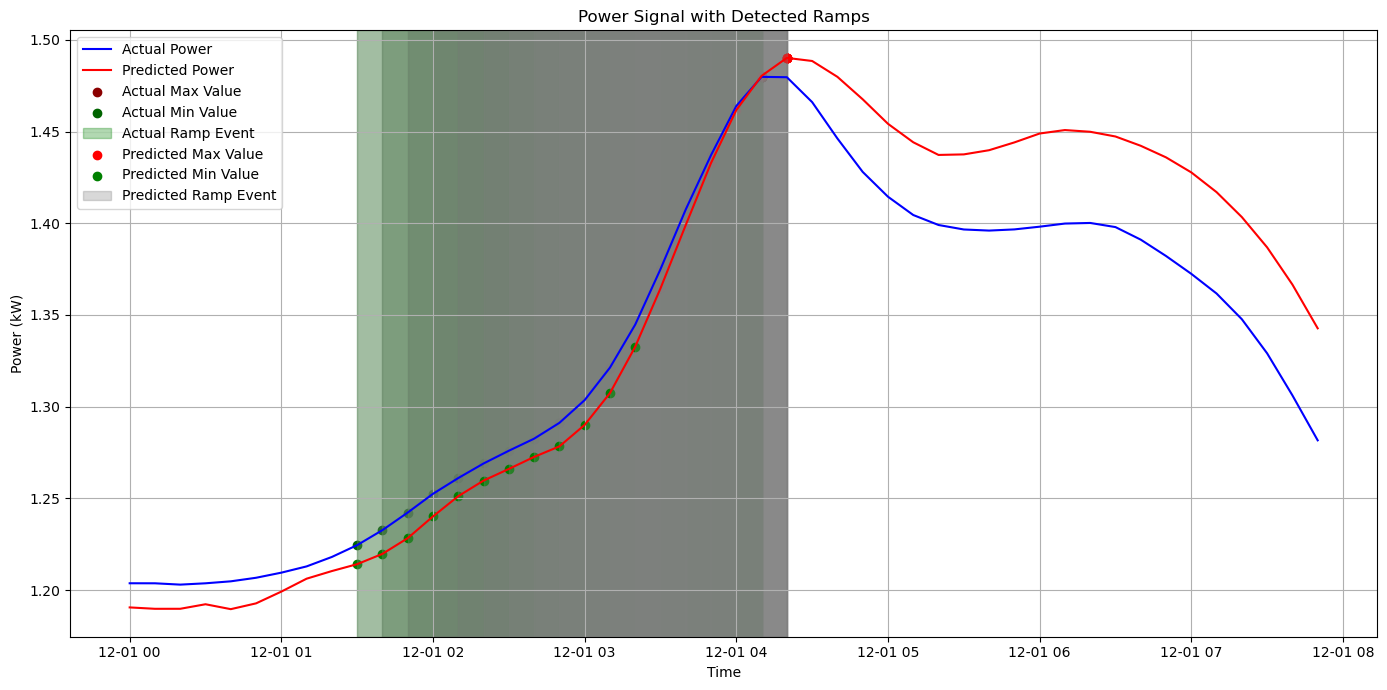

Detected Ramps in Actual Data:
            Start_Time            End_Time           Max_Index  \
0  2018-12-01 01:30:00 2018-12-01 03:30:00 2018-12-01 03:30:00   
1  2018-12-01 01:40:00 2018-12-01 03:40:00 2018-12-01 03:40:00   
2  2018-12-01 01:50:00 2018-12-01 03:50:00 2018-12-01 03:50:00   
3  2018-12-01 02:00:00 2018-12-01 04:00:00 2018-12-01 04:00:00   
4  2018-12-01 02:10:00 2018-12-01 04:10:00 2018-12-01 04:10:00   
5  2018-12-01 02:20:00 2018-12-01 04:20:00 2018-12-01 04:10:00   
6  2018-12-01 02:30:00 2018-12-01 04:30:00 2018-12-01 04:10:00   
7  2018-12-01 02:40:00 2018-12-01 04:40:00 2018-12-01 04:10:00   
8  2018-12-01 02:50:00 2018-12-01 04:50:00 2018-12-01 04:10:00   
9  2018-12-01 03:00:00 2018-12-01 05:00:00 2018-12-01 04:10:00   
10 2018-12-01 03:10:00 2018-12-01 05:10:00 2018-12-01 04:10:00   

             Min_Index  Magnitude Direction  
0  2018-12-01 01:30:00   0.150446        Up  
1  2018-12-01 01:40:00   0.174831        Up  
2  2018-12-01 01:50:00   0.194868     

In [470]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

# Parameters
installed_capacity = 1  # in kW (normalized, so it's 1)
ramp_threshold_percentage = 15  # percentage
ramp_duration_minutes =120  # 2 hours in minutes
interval_minutes = 10  # Time resolution in minutes
ramp_duration_intervals = ramp_duration_minutes // interval_minutes  # Number of 10-minute intervals in 4 hours

# Ramp detection function with direction
def detect_ramps(power_series, threshold_percentage, duration_intervals, installed_capacity):
    threshold_value = (threshold_percentage / 100) * installed_capacity
    ramps = []

    for i in range(len(power_series) - duration_intervals):
        start_index = i
        end_index = i + duration_intervals

        power_range = power_series.iloc[start_index:end_index + 1]
        min_power = power_range.min()
        max_power = power_range.max()
        power_diff = max_power - min_power

        if power_diff >= threshold_value:
            ramp_direction = 'Up' if max_power == power_range.iloc[-1] else 'Down'
            ramps.append({
                'Start_Time': power_series.index[start_index],
                'End_Time': power_series.index[end_index],
                'Max_Index': power_range.idxmax(),
                'Min_Index': power_range.idxmin(),
                'Magnitude': power_diff,
                'Direction': ramp_direction
            })

    return pd.DataFrame(ramps)

# Assuming 'actual_data' and 'predicted_data' are your DataFrames with normalized power data
# Detect ramps in actual data using the detect_ramps function
ramps_actual = detect_ramps(actual_data['Og'], ramp_threshold_percentage, ramp_duration_intervals, installed_capacity)

# Detect ramps in predicted data
ramps_predicted = detect_ramps(predicted_data['Pred'], ramp_threshold_percentage, ramp_duration_intervals, installed_capacity)

# Plotting the Results
plt.figure(figsize=(14, 7))
plt.plot(actual_data.index, actual_data['Og'], label='Actual Power', color='blue')
plt.plot(predicted_data.index, predicted_data['Pred'], label='Predicted Power', color='red')

# Add scatter plots for each ramp event for actual_data
for i, event in ramps_actual.iterrows():
    plt.scatter(event['Max_Index'], actual_data.loc[event['Max_Index'], 'Og'], color='darkred', label='Actual Max Value' if i == 0 else "")
    plt.scatter(event['Min_Index'], actual_data.loc[event['Min_Index'], 'Og'], color='darkgreen', label='Actual Min Value' if i == 0 else "")
    plt.axvspan(event['Min_Index'], event['Max_Index'], color='green', alpha=0.3, label='Actual Ramp Event' if i == 0 else "")

# Add scatter plots for each ramp event for predicted_data
for i, event in ramps_predicted.iterrows():
    plt.scatter(event['Max_Index'], predicted_data.loc[event['Max_Index'], 'Pred'], color='red', label='Predicted Max Value' if i == 0 else "")
    plt.scatter(event['Min_Index'], predicted_data.loc[event['Min_Index'], 'Pred'], color='green', label='Predicted Min Value' if i == 0 else "")
    plt.axvspan(event['Min_Index'], event['Max_Index'], color='gray', alpha=0.3, label='Predicted Ramp Event' if i == 0 else "")

# Adding labels and legend
plt.xlabel('Time')
plt.ylabel('Power (kW)')
plt.title('Power Signal with Detected Ramps')
plt.legend()
plt.grid(True)
plt.tight_layout()

# Show the plot
plt.show()

# Print detected ramps
print("Detected Ramps in Actual Data:")
print(ramps_actual)
print("\nDetected Ramps in Predicted Data:")
print(ramps_predicted)

# Function to match ramps within a tolerance
def match_ramps(ramps_actual, ramps_predicted, tolerance_minutes):
    tolerance = pd.Timedelta(minutes=tolerance_minutes)
    matches = 0

    matched_predicted_indices = set()
    
    for _, actual_ramp in ramps_actual.iterrows():
        for pred_index, predicted_ramp in ramps_predicted.iterrows():
            if pred_index not in matched_predicted_indices:
                if abs(actual_ramp['Start_Time'] - predicted_ramp['Start_Time']) <= tolerance:
                    matches += 1
                    matched_predicted_indices.add(pred_index)
                    break

    return matches

# Calculate accuracy, precision, and recall
tolerance_minutes = 10
matches = match_ramps(ramps_actual, ramps_predicted, tolerance_minutes)

total_actual = len(ramps_actual)
total_predicted = len(ramps_predicted)

precision = matches / total_predicted if total_predicted > 0 else 0
recall = matches / total_actual if total_actual > 0 else 0
f1 = (2 * precision * recall) / (precision + recall) if (precision + recall) > 0 else 0

# Print accuracy results
print(f"Precision: {precision:.3f}")
print(f"Recall: {recall:.3f}")
print(f"F1-Score: {f1:.3f}")

print(f"Total Actual Ramps: {total_actual}")
print(f"Total Predicted Ramps: {total_predicted}")
print(f"Matches: {matches}")
